# Ansatz comparison (package client)

This notebook compares the Binary VQE and Fractional VQE ansatz options on a compact deterministic synthetic problem. It delegates execution to `scripts/generate_ansatz_comparison.py`, then displays the generated CSV and plots the rows with package plotting helpers.

In [1]:
from __future__ import annotations

import csv
import importlib
import sys
from pathlib import Path

from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise RuntimeError("Could not locate repository root containing pyproject.toml.")


ROOT = find_repo_root(Path.cwd().resolve())
for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

generate_ansatz_results = importlib.import_module(
    "scripts.generate_ansatz_comparison"
).main
plotting = importlib.import_module("vqe_portfolio.plotting")
plot_comparison_metric_bars = plotting.plot_comparison_metric_bars
plot_risk_return_comparison = plotting.plot_risk_return_comparison

OUTPUT_CSV = ROOT / "results" / "ansatz_comparison.csv"
IMAGE_DIR = ROOT / "notebooks" / "images"

## Generate ansatz comparison

In [2]:
generate_ansatz_results(
    [
        "--output",
        str(OUTPUT_CSV),
        "--asset-count",
        "4",
        "--seeds",
        "0,1,2",
        "--depth",
        "2",
        "--steps",
        "25",
        "--shots",
        "512",
    ]
)

Wrote 8 ansatz comparison rows to /workspaces/VQE_Portfolio_Optimization/results/ansatz_comparison.csv


0

## Display rows

In [3]:
with OUTPUT_CSV.open(newline="") as f:
    rows = list(csv.DictReader(f))


def markdown_table(rows: list[dict[str, str]], columns: list[str]) -> Markdown:
    header = "| " + " | ".join(columns) + " |"
    rule = "| " + " | ".join("---" for _ in columns) + " |"
    body = [
        "| " + " | ".join(str(row.get(col, "")) for col in columns) + " |"
        for row in rows
    ]
    return Markdown("\n".join([header, rule, *body]))


display(
    markdown_table(
        rows,
        [
            "method",
            "ansatz",
            "objective_family",
            "reported_weighting",
            "seed_count",
            "mean_objective",
            "std_objective",
            "mean_return",
            "mean_risk",
            "feasible_rate",
        ],
    )
)

| method | ansatz | objective_family | reported_weighting | seed_count | mean_objective | std_objective | mean_return | mean_risk | feasible_rate |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Classical exhaustive search | - | binary_qubo | equal_weight_selected | 1 | 0.285137 | 0.000000 | 0.102055 | 0.174865 | 1.000000 |
| Binary VQE | ry_cz | binary_qubo | equal_weight_selected | 3 | 0.289414 | 0.006049 | 0.107872 | 0.177643 | 0.978516 |
| Binary VQE | ry_rz_cz | binary_qubo | equal_weight_selected | 3 | 0.334814 | 0.038166 | 0.132564 | 0.193123 | 0.968750 |
| Binary VQE | strongly_entangling | binary_qubo | equal_weight_selected | 3 | 0.308159 | 0.024062 | 0.118544 | 0.184414 | 0.981771 |
| Classical exact Markowitz | - | fractional_simplex | simplex_weights | 1 | -0.053292 | 0.000000 | 0.125046 | 0.133935 | 1.000000 |
| Fractional VQE | ry | fractional_simplex | simplex_weights | 3 | -0.053080 | 0.000161 | 0.125869 | 0.134895 | 1.000000 |
| Fractional VQE | ry_cz | fractional_simplex | simplex_weights | 3 | -0.053107 | 0.000178 | 0.125285 | 0.134327 | 1.000000 |
| Fractional VQE | ry_rz_cz | fractional_simplex | simplex_weights | 3 | -0.053182 | 0.000036 | 0.124302 | 0.133337 | 1.000000 |

## Plots

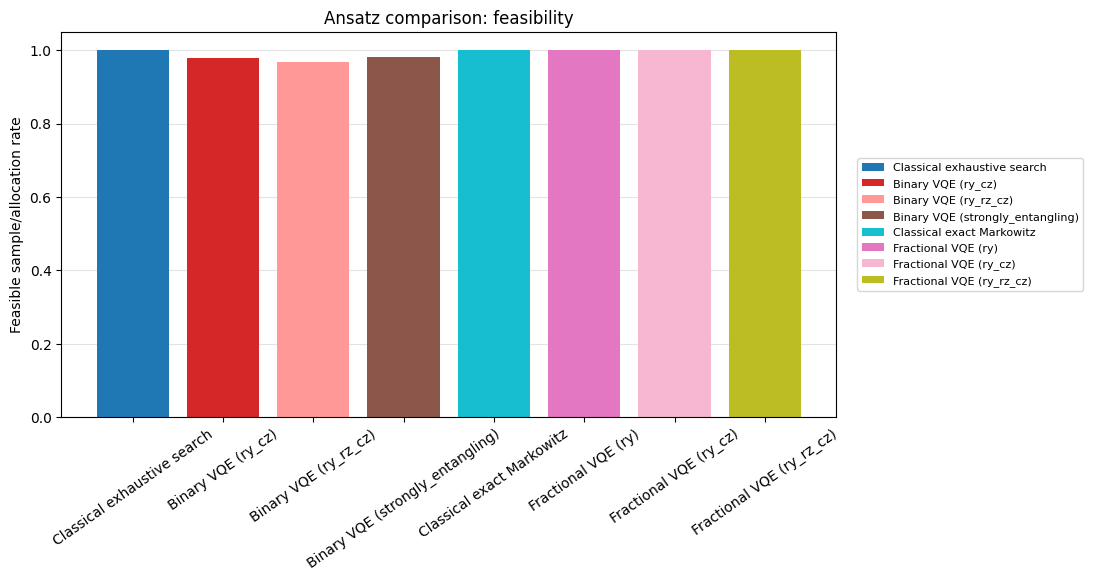

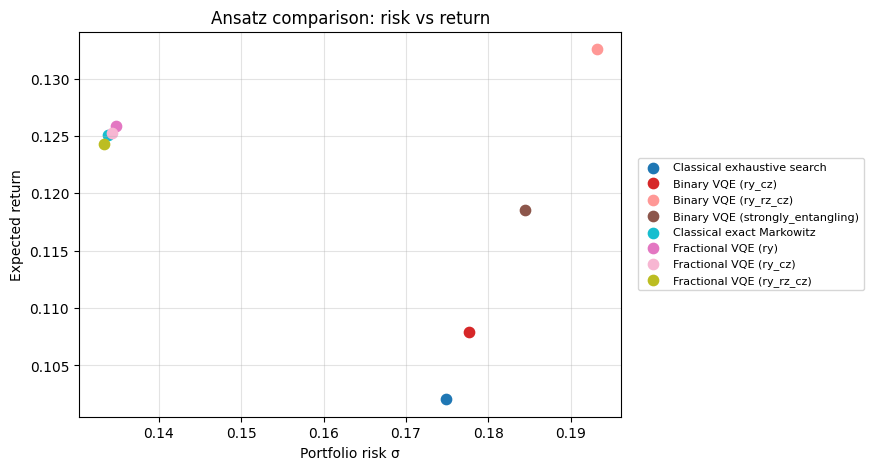

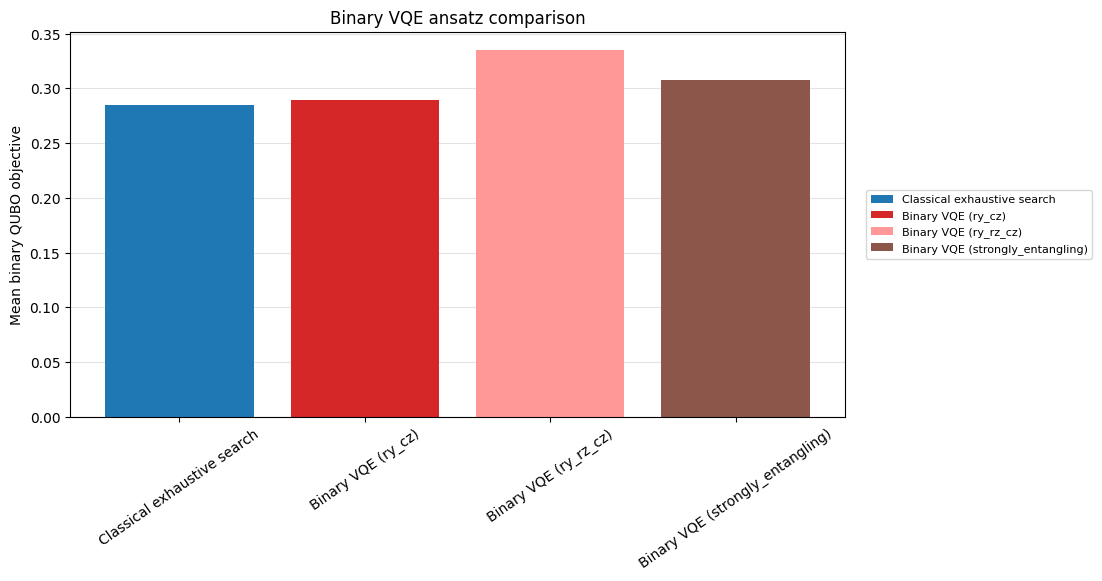

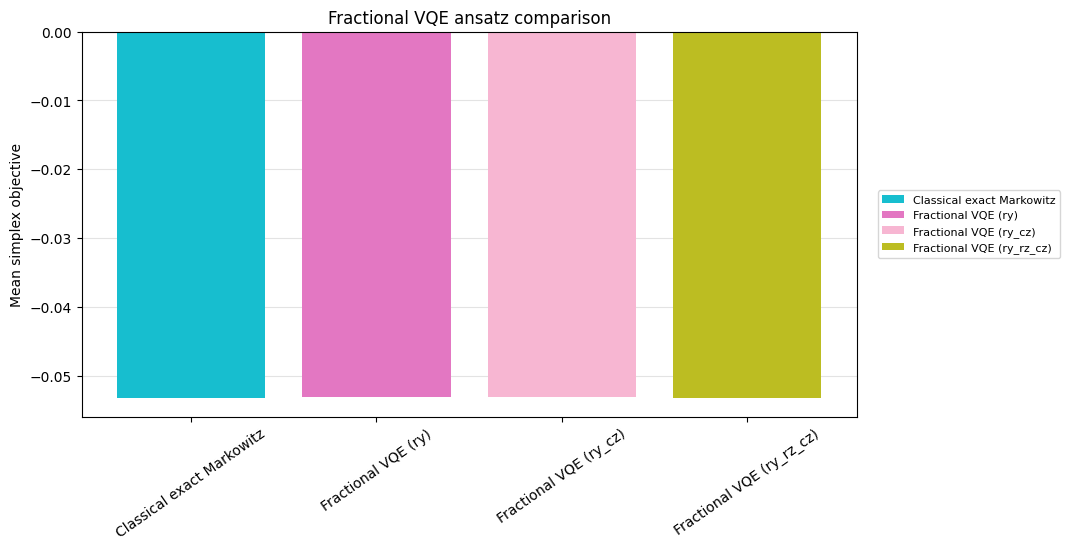

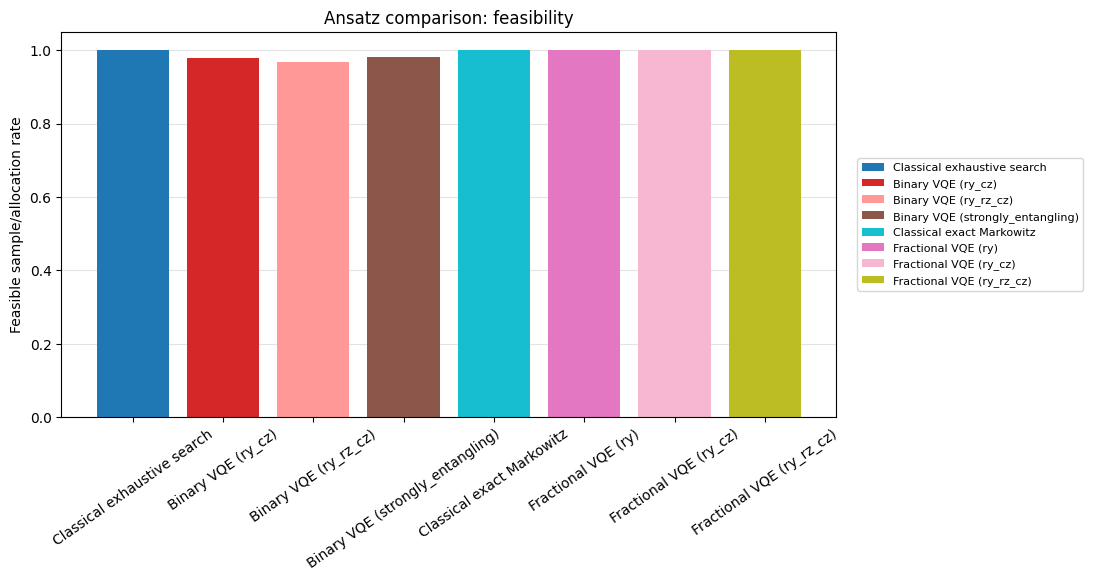

In [4]:
binary_rows = [row for row in rows if row["objective_family"] == "binary_qubo"]
fractional_rows = [
    row for row in rows if row["objective_family"] == "fractional_simplex"
]

plot_risk_return_comparison(
    rows,
    title="Ansatz comparison: risk vs return",
    outpath=IMAGE_DIR / "Ansatz_Comparison_Risk_Return.png",
)

plot_comparison_metric_bars(
    binary_rows,
    metric="mean_objective",
    ylabel="Mean binary QUBO objective",
    title="Binary VQE ansatz comparison",
    outpath=IMAGE_DIR / "Ansatz_Comparison_Binary_Objective.png",
)

plot_comparison_metric_bars(
    fractional_rows,
    metric="mean_objective",
    ylabel="Mean simplex objective",
    title="Fractional VQE ansatz comparison",
    outpath=IMAGE_DIR / "Ansatz_Comparison_Fractional_Objective.png",
)

plot_comparison_metric_bars(
    rows,
    metric="feasible_rate",
    ylabel="Feasible sample/allocation rate",
    title="Ansatz comparison: feasibility",
    outpath=IMAGE_DIR / "Ansatz_Comparison_Feasibility.png",
)